### Phase 0 & 1: Comprehensive Theory Practice Test

**Phase 0: Elementary Foundations & Math Primitives**
1. *(Easy)* Find the exact Intersection ($A \cap B$) of Set A = `{2, 4, 6, 8}` and Set B = `{4, 8, 12}`. Answer: {4, 8}
2. *(Medium)* Evaluate this summation manually: $\sum_{i=1}^4 (3i - 1)$.
3. *(Hard)* If Set X contains exactly 5 elements and Set Y contains exactly 3 elements, what is the *maximum* possible size of their Union ($X \cup Y$), and what is the *minimum* possible size?
4. *(Advanced)* Explain the conceptual difference between a *discrete integer* and a *continuous float*. Give one example of an ML hyperparameter that must be discrete, and one that must be continuous.

**Phase 1 | Module 1: The Algebra Bridge (Functions, Logs, & Info Theory)**
1. *(Easy)* Simplify this expression down to a single number: $\log_2(16) + \log_3(9)$.
2. *(Medium)* Solve for $x$ (you can leave the natural log in your final answer): $e^{2x} = 20$.
3. *(Hard)* Using the Product and Power rules of logarithms, completely expand this expression: $\ln\left(\frac{e^3 \cdot x^2}{y}\right)$. *(Hint: Division becomes subtraction!)*
4. *(Advanced)* Calculate the Information (in bits) of an event that has exactly a 12.5% ($\frac{1}{8}$) chance of occurring.

**Phase 1 | Module 2: Trigonometry & Waves**
1. *(Easy)* Convert 120 degrees into radians. (Leave $\pi$ in your answer as a simplified fraction).
2. *(Medium)* On the Unit Circle, what are the exact $(x, y)$ coordinates (meaning the Cosine and Sine) at exactly $\pi$ radians?
3. *(Hard)* If a robotic wheel has a radius of 4 meters and makes exactly 3 full rotations, what is the exact mathematical distance it traveled? (Leave $\pi$ in your answer).
4. *(Advanced)* Explain intuitively why the Sine and Cosine waves are exactly $\frac{\pi}{2}$ radians out of phase. How does this phase shift help a Transformer's Positional Encoding understand the order of words?

**Phase 1 | Module 3: Algorithmic Complexity**
1. *(Easy)* What is the Big-O time complexity of checking every single item in an unsorted array of $N$ items until you find your target?
2. *(Medium)* Why does searching a Hash Map have a time complexity of $O(1)$ instead of $O(N)$? What is the "mathematical shredder" doing?
3. *(Hard)* If an $O(N)$ algorithm takes 2 seconds to process 10,000 items, roughly how many seconds will an $O(N^2)$ algorithm take to process 100,000 items (assuming the same 2-second baseline for 10k items)?
4. *(Advanced)* Explain why the Transformer Self-Attention mechanism suffers from $O(N^2)$ complexity. What exactly is the model comparing that causes this bottleneck as the prompt gets longer?

**Phase 1 | Module 4: Core Data Structures (Trees, OOP, Stacks, Queues)**
1. *(Easy)* Which data structure uses LIFO (Last-In, First-Out): a Stack or a Queue?
2. *(Medium)* In Object-Oriented Programming (OOP), what is the exact conceptual difference between a `Class` and an `Object`? 
3. *(Hard)* Inside a Python class method, what is the strict purpose of the `self` keyword? 
4. *(Advanced)* Trace the mathematical execution of our `calculate_factorial(4)` code through the Call Stack. How many distinct function frames are pushed onto the Stack before the computer finally hits the Base Case and begins popping them off?

**Phase 1 | Module 5: Graph Theory Fundamentals**
1. *(Easy)* In a graph representing a one-way street network, are the edges Directed or Undirected?
2. *(Medium)* Write out the exact Python Adjacency List (Dictionary) for a triangle of 3 nodes (A, B, C) where every node is connected to every other node via an *Undirected* edge.
3. *(Hard)* In Kaldi-style Classical ASR, we decode audio using Weighted Finite State Transducers (WFSTs). In a graph where nodes are "states" and edges are "word transitions", what does the "Weight" on the edge usually represent mathematically?
4. *(Advanced)* How does a Knowledge Graph differ from a standard neural network in terms of representing factual truth? Why are we plugging LLMs into Knowledge Graphs today?

**Phase 1 | Module 6: Dynamic Programming & Recursion**
1. *(Easy)* What are the two mandatory components of any valid recursive function?
2. *(Medium)* Define "Memoization" in your own words using the supermarket or notebook analogy.
3. *(Hard)* Why exactly does the naive recursive Fibonacci approach result in an exponential $O(2^N)$ time complexity? What is the computer doing wrong?
4. *(Advanced)* Explain conceptually how the Viterbi Algorithm uses Dynamic Programming to decode speech efficiently without trying every single possible word combination in the dictionary.

---

### Phase 1 Guided Capstone Project: "The Bigram Tokenizer & Graph"

**The Objective:**
You will build a pure Python/NumPy pipeline that processes raw text, tokenizes it using a Hash Map, builds an OOP-based directed graph of word transitions, and uses dynamic/recursive logic to calculate paths.

**The Rules:**
* **NO Starter Code.** You must write every line from scratch in a fresh Jupyter Notebook.
* **NO External DL Libraries.** Use only standard Python, `numpy`, `time`, and `matplotlib`/`networkx` (if you wish to visualize).

**The Pipeline Requirements:**
1. **The Corpus:** Define a variable with a few sentences of text. (e.g., `"the dog barked. the cat meowed. the dog chased the cat."`)
2. **The Hash Map Tokenizer:** Write a function that splits the text into words, assigns a unique integer ID to every unique word, and stores this in an $O(1)$ dictionary vocabulary. 
3. **The OOP Directed Graph:** Build a `class BigramGraph:`. Using adjacency lists, build a *Directed* Graph where the nodes are the integer Word IDs. Add a directed edge from Word A to Word B every time Word B immediately follows Word A in your corpus.
4. **Edge Weights:** Upgrade your graph so that the edges have "weights". The weight should be the *count* of how many times Word A transitioned to Word B. 
5. **The DP/Recursive Search:** Write a function that takes a starting word ID, looks at your graph, and uses a recursive or greedy loop to generate a 5-word sentence by always choosing the highest-weight edge (the most probable next word).

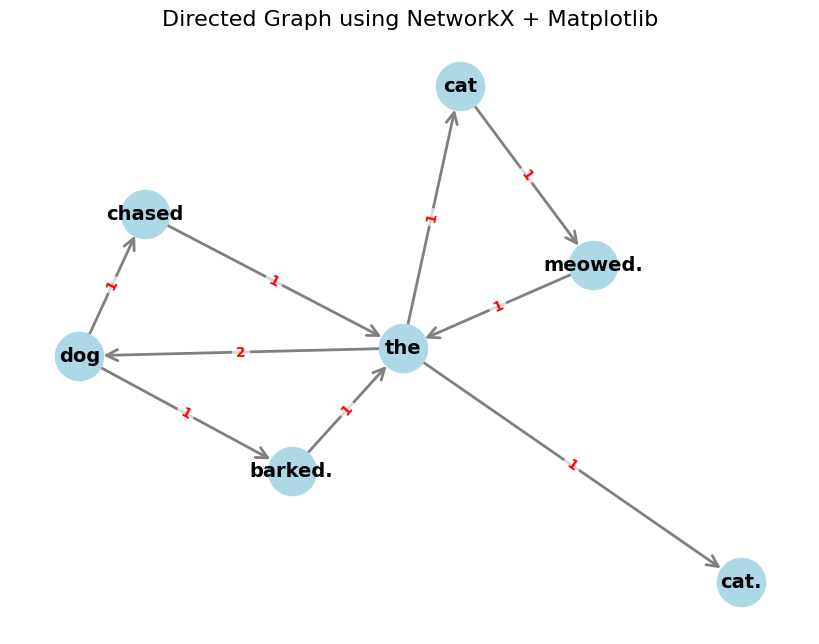

In [7]:
from typing import Dict, Set, Tuple
from networkx import DiGraph, spring_layout, draw, get_edge_attributes, draw_networkx_edge_labels
import matplotlib.pyplot as plt

class BigramGraph:
    def __init__(self, text: str):
        self.adjacency_list: Dict[int, Set[int]] = {}
        self.edges: Dict[Tuple[int, int], int] = {}
        self.nx_graph = DiGraph()
        self.text = str(text)
        self.token_map = BigramGraph.tokenizer(text)
        self.reverse_token_map = {idx: token for token, idx in self.token_map.items()} 
        self.build_graph()
    
    def build_graph(self):
        text_tokens = self.text.split(" ")
        for idx in range(len(text_tokens) - 1):
            word_id, next_word_id = self.token_map[text_tokens[idx]], self.token_map[text_tokens[idx + 1]]
            self.add_edge(word_id, next_word_id)


    @staticmethod
    def tokenizer(text: str) -> Dict[str, int]:
        return {token.strip(): idx for idx, token in enumerate(set(text.split(" ")))}

    def add_node(self, node:int):
        if node not in self.adjacency_list:
            self.adjacency_list[node] = set()
            self.nx_graph.add_node(node)
    
    def add_edge(self, node1_id:int, node2_id:int):
        node1, node2 = self.reverse_token_map.get(node1_id, ""), self.reverse_token_map.get(node2_id, "")
        self.add_node(node1)
        self.add_node(node2)

        edge_weight = 1
        if node2 in self.adjacency_list[node1]:
            edge_weight = self.edges[(node1, node2)]
            edge_weight += 1 # increasing edge weight for the new association
        else:
            self.adjacency_list[node1].add(node2)
            self.nx_graph.add_edge(node1, node2)
        self.edges[(node1, node2)] = edge_weight
        self.nx_graph.add_edge(node1, node2, weight=edge_weight)

    def search(self, word_id: int, word_limit = 5):
        if word_id not in self.adjacency_list or word_limit <= 0:
            return ""
        edge_keys = list(self.edges.keys())
        next_word_id = sorted(edge_keys, key=lambda x: self.edges[x] if x[0]==word_id else 0, reverse=True)[0][1]
        return f"{self.reverse_token_map[word_id]} {self.search(next_word_id, word_limit = word_limit - 1)}"

    def view(self):
        # Draw the graph
        plt.figure(figsize=(8, 6))

        pos = spring_layout(self.nx_graph, seed=42)        # positions for all nodes

        draw(self.nx_graph, pos,
                with_labels=True,                 # show node labels
                node_color='lightblue',
                node_size=1200,
                font_size=14,
                font_weight='bold',
                arrows=True,                      # show arrowheads
                arrowstyle='->',                  # arrow style
                arrowsize=20,                     # arrow size
                edge_color='gray',
                width=2)
        edge_labels = get_edge_attributes(self.nx_graph, 'weight')
        draw_networkx_edge_labels(self.nx_graph, pos,
                             edge_labels=edge_labels,
                             font_size=10,
                             font_color='red',
                             font_weight='bold',
                             label_pos=0.5,        # 0.5 = middle of edge
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=3))
        plt.title("Directed Graph using NetworkX + Matplotlib", fontsize=16)
        plt.axis('off')   # turn off axis
        plt.show()


graph = BigramGraph("the dog barked. the cat meowed. the dog chased the cat.")
print(graph.search(1))
print(graph.search(0))
print(graph.search(3))
graph.view()


        